In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
%pip install mysql-connector-python

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/17.7 MB 1.9 MB/s eta 0:00:10
   -- ------------------------------------- 1.0/17.7 MB 1.9 MB/s eta 0:00:09
   -- ------------------------------------- 1.3/17.7 MB 2.0 MB/s eta 0:00:09
   ---- ----------------------------------- 1.8/17.7 MB 2.0 MB/s eta 0:00:08
   ----- ---------------------------------- 2.4/17.7 MB 2.1 MB/s eta 0:00:08
   ------ --------------------------------- 2.9/17.7 MB 2.1 MB/s eta 0:00:07
   ------- -------------------------------- 3.4/17.7 MB 2.1 MB/s eta 0:00:07
   -------- ------------------------------- 3.7/17.7 MB 2.2 MB/s eta 0:00:07
   --------- ------------------------------ 4.2/17.7 MB 2.2 MB/s eta 0:00:07
   ---------- ----------------------------- 4.7/17.7 MB 2.2 MB/s eta 0:00:06
   ----------- ---------------------------- 5.2/17.7 MB 2.2 MB/s eta 0:00:06
   ----------

In [1]:
import mysql.connector

print("MySQL connector imported successfully!")

MySQL connector imported successfully!


In [2]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="gokul",
    database="hdfc_bank"
)

print("Connected to HDFC Bank database successfully!")

Connected to HDFC Bank database successfully!


In [3]:
cursor = connection.cursor()

cursor.execute("SHOW TABLES")

tables = cursor.fetchall()

for table in tables:
    print(table[0])

balance_sheet
banking_kpis
cash_flow
profit_loss


In [6]:
profit_loss = pd.read_sql("SELECT * FROM profit_loss ORDER BY financial_year", connection)
balance_sheet = pd.read_sql("SELECT * FROM balance_sheet ORDER BY financial_year", connection)
cash_flow = pd.read_sql("SELECT * FROM cash_flow ORDER BY financial_year", connection)
banking_kpis = pd.read_sql("SELECT * FROM banking_kpis ORDER BY financial_year", connection)

print("All tables loaded successfully!")

All tables loaded successfully!


C:\Users\gokul\AppData\Local\Temp\ipykernel_2536\2946029055.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  profit_loss = pd.read_sql("SELECT * FROM profit_loss ORDER BY financial_year", connection)
C:\Users\gokul\AppData\Local\Temp\ipykernel_2536\2946029055.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  balance_sheet = pd.read_sql("SELECT * FROM balance_sheet ORDER BY financial_year", connection)
C:\Users\gokul\AppData\Local\Temp\ipykernel_2536\2946029055.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cash_fl

In [7]:
print("Profit & Loss:", profit_loss.shape)
print("Balance Sheet:", balance_sheet.shape)
print("Cash Flow:", cash_flow.shape)
print("Banking KPIs:", banking_kpis.shape)

Profit & Loss: (5, 10)
Balance Sheet: (5, 10)
Cash Flow: (5, 5)
Banking KPIs: (5, 13)


In [8]:
display(profit_loss)

,financial_year,sales,expenses,operating_profit,other_income,depreciation,interest,profit_before_tax,tax,net_profit
0,FY2020-21,128552.40,52456.53,76095.87,27332.88,1385.01,59247.59,42796.15,10939.38,31833.21
1,FY2021-22,135936.41,56556.96,79379.45,31758.99,1680.73,58584.33,50873.38,12722.48,38052.75
2,FY2022-23,170754.05,63042.30,107711.75,33912.05,2345.47,77779.94,61498.39,15349.69,45997.11
3,FY2023-24,283649.02,174195.54,109453.48,124345.75,3092.08,154138.55,76568.60,11122.10,64062.04
4,FY2024-25,336367.43,186974.45,149392.98,134548.50,3805.23,183894.20,96242.05,22801.88,70792.25


In [9]:
display(balance_sheet)

,financial_year,equity_capital,reserves,borrowings,other_liabilities,total_liabilities,net_block,investments,other_assets,total_assets
0,FY2020-21,551.28,209258.90,1511417.62,78278.83,1799506.63,5248.35,438823.11,1355435.17,1799506.63
1,FY2021-22,554.55,246771.62,1784969.53,90638.60,2122934.30,6432.07,449263.86,1667238.37,2122934.30
2,FY2022-23,557.97,288879.53,2139211.91,101783.03,2530432.44,8431.35,511581.71,2010419.38,2530432.44
3,FY2023-24,759.69,455635.56,3107502.74,466296.27,4030194.26,12603.76,1005681.63,3011908.87,4030194.26
4,FY2024-25,765.22,521024.17,3345503.80,524816.64,4392109.83,15257.94,1186472.89,3190379.00,4392109.83


In [10]:
display(cash_flow)

,financial_year,cash_from_operating_activity,cash_from_investing_activity,cash_from_financing_activity,net_cash_flow
0,FY2020-21,42476.45,-1822.70,-7321.35,33332.40
1,FY2021-22,-11959.57,-2051.23,48124.02,34113.22
2,FY2022-23,20813.70,-2992.18,23940.56,41762.08
3,FY2023-24,19069.34,16600.42,-3983.06,31686.70
4,FY2024-25,127241.84,-3650.91,-102477.54,21113.39


In [11]:
display(banking_kpis)

,financial_year,total_advances,total_deposits,casa_deposits,casa_ratio,gnpa_ratio,net_npa_ratio,provision_coverage_ratio,nim,roa,roe,car,cost_to_income_ratio
0,FY2020-21,1132837.0,1335060.0,NaN,NaN,1.32,0.40,69.81,4.10,1.97,16.60,18.79,36.3
1,FY2021-22,1368821.0,1559217.0,751050.0,48.2,1.17,0.32,72.69,4.00,2.03,16.90,18.90,36.9
2,FY2022-23,1600586.0,1883395.0,835989.0,44.4,1.12,0.27,75.80,4.10,2.07,17.39,19.30,40.4
3,FY2023-24,2484862.0,2379786.0,NaN,38.2,1.24,0.33,74.04,3.53,1.98,16.10,18.80,40.2
4,FY2024-25,2619609.0,2714715.0,944561.0,34.8,1.33,0.43,67.86,3.48,1.91,14.56,19.60,40.5


In [12]:
print("Profit & Loss")
print(profit_loss.dtypes)

print("\nBalance Sheet")
print(balance_sheet.dtypes)

print("\nCash Flow")
print(cash_flow.dtypes)

print("\nBanking KPIs")
print(banking_kpis.dtypes)

Profit & Loss
financial_year        object
sales                float64
expenses             float64
operating_profit     float64
other_income         float64
depreciation         float64
interest             float64
profit_before_tax    float64
tax                  float64
net_profit           float64
dtype: object

Balance Sheet
financial_year        object
equity_capital       float64
reserves             float64
borrowings           float64
other_liabilities    float64
total_liabilities    float64
net_block            float64
investments          float64
other_assets         float64
total_assets         float64
dtype: object

Cash Flow
financial_year                   object
cash_from_operating_activity    float64
cash_from_investing_activity    float64
cash_from_financing_activity    float64
net_cash_flow                   float64
dtype: object

Banking KPIs
financial_year               object
total_advances              float64
total_deposits              float64
casa_deposits   

In [13]:
print("Profit & Loss missing values:")
print(profit_loss.isnull().sum())

print("\nBalance Sheet missing values:")
print(balance_sheet.isnull().sum())

print("\nCash Flow missing values:")
print(cash_flow.isnull().sum())

print("\nBanking KPIs missing values:")
print(banking_kpis.isnull().sum())

Profit & Loss missing values:
financial_year       0
sales                0
expenses             0
operating_profit     0
other_income         0
depreciation         0
interest             0
profit_before_tax    0
tax                  0
net_profit           0
dtype: int64

Balance Sheet missing values:
financial_year       0
equity_capital       0
reserves             0
borrowings           0
other_liabilities    0
total_liabilities    0
net_block            0
investments          0
other_assets         0
total_assets         0
dtype: int64

Cash Flow missing values:
financial_year                  0
cash_from_operating_activity    0
cash_from_investing_activity    0
cash_from_financing_activity    0
net_cash_flow                   0
dtype: int64

Banking KPIs missing values:
financial_year              0
total_advances              0
total_deposits              0
casa_deposits               2
casa_ratio                  1
gnpa_ratio                  0
net_npa_ratio               0
pro

In [14]:
print("Profit & Loss duplicates:", profit_loss["financial_year"].duplicated().sum())
print("Balance Sheet duplicates:", balance_sheet["financial_year"].duplicated().sum())
print("Cash Flow duplicates:", cash_flow["financial_year"].duplicated().sum())
print("Banking KPIs duplicates:", banking_kpis["financial_year"].duplicated().sum())

Profit & Loss duplicates: 0
Balance Sheet duplicates: 0
Cash Flow duplicates: 0
Banking KPIs duplicates: 0


In [15]:
#Net Profit YoY Growth
profit_loss["net_profit_yoy_pct"] = (
    profit_loss["net_profit"].pct_change() * 100
).round(2)

display(
    profit_loss[
        ["financial_year", "net_profit", "net_profit_yoy_pct"]
    ]
)

,financial_year,net_profit,net_profit_yoy_pct
0,FY2020-21,31833.21,NaN
1,FY2021-22,38052.75,19.54
2,FY2022-23,45997.11,20.88
3,FY2023-24,64062.04,39.27
4,FY2024-25,70792.25,10.51


In [16]:
#Find the year with the highest Net Profit growth
highest_profit_growth = profit_loss.loc[
    profit_loss["net_profit_yoy_pct"].idxmax()
]

print("Year with highest Net Profit growth:",
      highest_profit_growth["financial_year"])

print("Net Profit growth:",
      highest_profit_growth["net_profit_yoy_pct"], "%")

Year with highest Net Profit growth: FY2023-24
Net Profit growth: 39.27 %


In [17]:
#Calculate Net Profit CAGR
start_profit = profit_loss.iloc[0]["net_profit"]
end_profit = profit_loss.iloc[-1]["net_profit"]

years = len(profit_loss) - 1

net_profit_cagr = (
    (end_profit / start_profit) ** (1 / years) - 1
) * 100

print("Starting Net Profit:", start_profit)
print("Ending Net Profit:", end_profit)
print("Net Profit CAGR:", round(net_profit_cagr, 2), "%")

Starting Net Profit: 31833.21
Ending Net Profit: 70792.25
Net Profit CAGR: 22.12 %


In [18]:
#Calculate Sales YoY Growth
profit_loss["sales_yoy_pct"] = (
    profit_loss["sales"].pct_change() * 100
).round(2)

display(
    profit_loss[
        ["financial_year", "sales", "sales_yoy_pct"]
    ]
)

,financial_year,sales,sales_yoy_pct
0,FY2020-21,128552.40,NaN
1,FY2021-22,135936.41,5.74
2,FY2022-23,170754.05,25.61
3,FY2023-24,283649.02,66.12
4,FY2024-25,336367.43,18.59


In [19]:
#Calculate Net Profit Margin
profit_loss["net_profit_margin_pct"] = (
    profit_loss["net_profit"] / profit_loss["sales"] * 100
).round(2)

display(
    profit_loss[
        ["financial_year", "sales", "net_profit", "net_profit_margin_pct"]
    ]
)

,financial_year,sales,net_profit,net_profit_margin_pct
0,FY2020-21,128552.40,31833.21,24.76
1,FY2021-22,135936.41,38052.75,27.99
2,FY2022-23,170754.05,45997.11,26.94
3,FY2023-24,283649.02,64062.04,22.58
4,FY2024-25,336367.43,70792.25,21.05


In [20]:
#Calculate Operating Profit Margin
profit_loss["operating_profit_margin_pct"] = (
    profit_loss["operating_profit"] / profit_loss["sales"] * 100
).round(2)

display(
    profit_loss[
        ["financial_year", "sales", "operating_profit", "operating_profit_margin_pct"]
    ]
)

,financial_year,sales,operating_profit,operating_profit_margin_pct
0,FY2020-21,128552.40,76095.87,59.19
1,FY2021-22,135936.41,79379.45,58.39
2,FY2022-23,170754.05,107711.75,63.08
3,FY2023-24,283649.02,109453.48,38.59
4,FY2024-25,336367.43,149392.98,44.41


In [21]:
#Calculate Expense Growth
profit_loss["expense_yoy_pct"] = (
    profit_loss["expenses"].pct_change() * 100
).round(2)

display(
    profit_loss[
        ["financial_year", "expenses", "expense_yoy_pct"]
    ]
)

,financial_year,expenses,expense_yoy_pct
0,FY2020-21,52456.53,NaN
1,FY2021-22,56556.96,7.82
2,FY2022-23,63042.30,11.47
3,FY2023-24,174195.54,176.32
4,FY2024-25,186974.45,7.34


In [22]:
#Calculate Expense-to-Sales Ratio
profit_loss["expense_ratio_pct"] = (
    profit_loss["expenses"] / profit_loss["sales"] * 100
).round(2)

display(
    profit_loss[
        ["financial_year", "sales", "expenses", "expense_ratio_pct"]
    ]
)

,financial_year,sales,expenses,expense_ratio_pct
0,FY2020-21,128552.40,52456.53,40.81
1,FY2021-22,135936.41,56556.96,41.61
2,FY2022-23,170754.05,63042.30,36.92
3,FY2023-24,283649.02,174195.54,61.41
4,FY2024-25,336367.43,186974.45,55.59


In [23]:
#Calculate Other Income YoY Growth
profit_loss["other_income_yoy_pct"] = (
    profit_loss["other_income"].pct_change() * 100
).round(2)

display(
    profit_loss[
        ["financial_year", "other_income", "other_income_yoy_pct"]
    ]
)

,financial_year,other_income,other_income_yoy_pct
0,FY2020-21,27332.88,NaN
1,FY2021-22,31758.99,16.19
2,FY2022-23,33912.05,6.78
3,FY2023-24,124345.75,266.67
4,FY2024-25,134548.50,8.21


In [24]:
#Find the year with the highest Other Income growth
highest_other_income_growth = profit_loss.loc[
    profit_loss["other_income_yoy_pct"].idxmax()
]

print("Year with highest Other Income growth:",
      highest_other_income_growth["financial_year"])

print("Other Income growth:",
      highest_other_income_growth["other_income_yoy_pct"], "%")

Year with highest Other Income growth: FY2023-24
Other Income growth: 266.67 %


In [25]:
#Calculate Advances YoY Growth
banking_kpis["advances_yoy_pct"] = (
    banking_kpis["total_advances"].pct_change() * 100
).round(2)

display(
    banking_kpis[
        ["financial_year", "total_advances", "advances_yoy_pct"]
    ]
)

,financial_year,total_advances,advances_yoy_pct
0,FY2020-21,1132837.0,NaN
1,FY2021-22,1368821.0,20.83
2,FY2022-23,1600586.0,16.93
3,FY2023-24,2484862.0,55.25
4,FY2024-25,2619609.0,5.42


In [26]:
#Calculate Deposits YoY Growth
banking_kpis["deposits_yoy_pct"] = (
    banking_kpis["total_deposits"].pct_change() * 100
).round(2)

display(
    banking_kpis[
        ["financial_year", "total_deposits", "deposits_yoy_pct"]
    ]
)

,financial_year,total_deposits,deposits_yoy_pct
0,FY2020-21,1335060.0,NaN
1,FY2021-22,1559217.0,16.79
2,FY2022-23,1883395.0,20.79
3,FY2023-24,2379786.0,26.36
4,FY2024-25,2714715.0,14.07


In [27]:
#Calculate Credit-to-Deposit Ratio
banking_kpis["credit_deposit_ratio_pct"] = (
    banking_kpis["total_advances"] /
    banking_kpis["total_deposits"] * 100
).round(2)

display(
    banking_kpis[
        ["financial_year",
         "total_advances",
         "total_deposits",
         "credit_deposit_ratio_pct"]
    ]
)

,financial_year,total_advances,total_deposits,credit_deposit_ratio_pct
0,FY2020-21,1132837.0,1335060.0,84.85
1,FY2021-22,1368821.0,1559217.0,87.79
2,FY2022-23,1600586.0,1883395.0,84.98
3,FY2023-24,2484862.0,2379786.0,104.42
4,FY2024-25,2619609.0,2714715.0,96.50


In [29]:
#Analyze CASA Ratio
display(
    banking_kpis[
        ["financial_year", "casa_deposits", "casa_ratio"]
    ]
)

,financial_year,casa_deposits,casa_ratio
0,FY2020-21,NaN,NaN
1,FY2021-22,751050.0,48.2
2,FY2022-23,835989.0,44.4
3,FY2023-24,NaN,38.2
4,FY2024-25,944561.0,34.8


In [30]:
banking_kpis["casa_ratio_change_pp"] = (
    banking_kpis["casa_ratio"].diff()
).round(2)

display(
    banking_kpis[
        ["financial_year", "casa_ratio", "casa_ratio_change_pp"]
    ]
)

,financial_year,casa_ratio,casa_ratio_change_pp
0,FY2020-21,NaN,NaN
1,FY2021-22,48.2,NaN
2,FY2022-23,44.4,-3.8
3,FY2023-24,38.2,-6.2
4,FY2024-25,34.8,-3.4


In [31]:
#Analyze Asset Quality
display(
    banking_kpis[
        [
            "financial_year",
            "gnpa_ratio",
            "net_npa_ratio",
            "provision_coverage_ratio"
        ]
    ]
)

,financial_year,gnpa_ratio,net_npa_ratio,provision_coverage_ratio
0,FY2020-21,1.32,0.40,69.81
1,FY2021-22,1.17,0.32,72.69
2,FY2022-23,1.12,0.27,75.80
3,FY2023-24,1.24,0.33,74.04
4,FY2024-25,1.33,0.43,67.86


In [32]:
banking_kpis["gnpa_change_pp"] = (
    banking_kpis["gnpa_ratio"].diff()
).round(2)

banking_kpis["net_npa_change_pp"] = (
    banking_kpis["net_npa_ratio"].diff()
).round(2)

display(
    banking_kpis[
        [
            "financial_year",
            "gnpa_ratio",
            "gnpa_change_pp",
            "net_npa_ratio",
            "net_npa_change_pp"
        ]
    ]
)

,financial_year,gnpa_ratio,gnpa_change_pp,net_npa_ratio,net_npa_change_pp
0,FY2020-21,1.32,NaN,0.40,NaN
1,FY2021-22,1.17,-0.15,0.32,-0.08
2,FY2022-23,1.12,-0.05,0.27,-0.05
3,FY2023-24,1.24,0.12,0.33,0.06
4,FY2024-25,1.33,0.09,0.43,0.10


In [33]:
#Analyze Provision Coverage Ratio
banking_kpis["pcr_change_pp"] = (
    banking_kpis["provision_coverage_ratio"].diff()
).round(2)

display(
    banking_kpis[
        [
            "financial_year",
            "provision_coverage_ratio",
            "pcr_change_pp"
        ]
    ]
)

,financial_year,provision_coverage_ratio,pcr_change_pp
0,FY2020-21,69.81,NaN
1,FY2021-22,72.69,2.88
2,FY2022-23,75.80,3.11
3,FY2023-24,74.04,-1.76
4,FY2024-25,67.86,-6.18


In [34]:
#Analyze Profitability KPIs
display(
    banking_kpis[
        [
            "financial_year",
            "nim",
            "roa",
            "roe"
        ]
    ]
)

,financial_year,nim,roa,roe
0,FY2020-21,4.10,1.97,16.60
1,FY2021-22,4.00,2.03,16.90
2,FY2022-23,4.10,2.07,17.39
3,FY2023-24,3.53,1.98,16.10
4,FY2024-25,3.48,1.91,14.56


In [35]:
banking_kpis["nim_change_pp"] = (
    banking_kpis["nim"].diff()
).round(2)

banking_kpis["roa_change_pp"] = (
    banking_kpis["roa"].diff()
).round(2)

banking_kpis["roe_change_pp"] = (
    banking_kpis["roe"].diff()
).round(2)

display(
    banking_kpis[
        [
            "financial_year",
            "nim",
            "nim_change_pp",
            "roa",
            "roa_change_pp",
            "roe",
            "roe_change_pp"
        ]
    ]
)

,financial_year,nim,nim_change_pp,roa,roa_change_pp,roe,roe_change_pp
0,FY2020-21,4.10,NaN,1.97,NaN,16.60,NaN
1,FY2021-22,4.00,-0.10,2.03,0.06,16.90,0.30
2,FY2022-23,4.10,0.10,2.07,0.04,17.39,0.49
3,FY2023-24,3.53,-0.57,1.98,-0.09,16.10,-1.29
4,FY2024-25,3.48,-0.05,1.91,-0.07,14.56,-1.54


In [36]:
#Analyze Capital Strength and Cost Efficiency
display(
    banking_kpis[
        [
            "financial_year",
            "car",
            "cost_to_income_ratio"
        ]
    ]
)

,financial_year,car,cost_to_income_ratio
0,FY2020-21,18.79,36.3
1,FY2021-22,18.90,36.9
2,FY2022-23,19.30,40.4
3,FY2023-24,18.80,40.2
4,FY2024-25,19.60,40.5


In [37]:
banking_kpis["car_change_pp"] = (
    banking_kpis["car"].diff()
).round(2)

banking_kpis["cost_income_change_pp"] = (
    banking_kpis["cost_to_income_ratio"].diff()
).round(2)

display(
    banking_kpis[
        [
            "financial_year",
            "car",
            "car_change_pp",
            "cost_to_income_ratio",
            "cost_income_change_pp"
        ]
    ]
)

,financial_year,car,car_change_pp,cost_to_income_ratio,cost_income_change_pp
0,FY2020-21,18.79,NaN,36.3,NaN
1,FY2021-22,18.90,0.11,36.9,0.6
2,FY2022-23,19.30,0.40,40.4,3.5
3,FY2023-24,18.80,-0.50,40.2,-0.2
4,FY2024-25,19.60,0.80,40.5,0.3


In [38]:
#Analyze Cash Flow
display(
    cash_flow[
        [
            "financial_year",
            "cash_from_operating_activity",
            "cash_from_investing_activity",
            "cash_from_financing_activity",
            "net_cash_flow"
        ]
    ]
)

,financial_year,cash_from_operating_activity,cash_from_investing_activity,cash_from_financing_activity,net_cash_flow
0,FY2020-21,42476.45,-1822.70,-7321.35,33332.40
1,FY2021-22,-11959.57,-2051.23,48124.02,34113.22
2,FY2022-23,20813.70,-2992.18,23940.56,41762.08
3,FY2023-24,19069.34,16600.42,-3983.06,31686.70
4,FY2024-25,127241.84,-3650.91,-102477.54,21113.39


In [39]:
highest_ocf = cash_flow.loc[
    cash_flow["cash_from_operating_activity"].idxmax()
]

print("Year with highest Operating Cash Flow:",
      highest_ocf["financial_year"])

print("Operating Cash Flow:",
      highest_ocf["cash_from_operating_activity"], "₹ Cr")

Year with highest Operating Cash Flow: FY2024-25
Operating Cash Flow: 127241.84 ₹ Cr


In [40]:
#Analyze the overall cash-flow pattern
cash_flow["net_cash_flow_yoy_pct"] = (
    cash_flow["net_cash_flow"].pct_change() * 100
).round(2)

display(
    cash_flow[
        [
            "financial_year",
            "net_cash_flow",
            "net_cash_flow_yoy_pct"
        ]
    ]
)

,financial_year,net_cash_flow,net_cash_flow_yoy_pct
0,FY2020-21,33332.40,NaN
1,FY2021-22,34113.22,2.34
2,FY2022-23,41762.08,22.42
3,FY2023-24,31686.70,-24.13
4,FY2024-25,21113.39,-33.37


In [41]:
#Balance Sheet growth analysis
balance_sheet["total_assets_yoy_pct"] = (
    balance_sheet["total_assets"].pct_change() * 100
).round(2)

balance_sheet["total_liabilities_yoy_pct"] = (
    balance_sheet["total_liabilities"].pct_change() * 100
).round(2)

display(
    balance_sheet[
        [
            "financial_year",
            "total_assets",
            "total_assets_yoy_pct",
            "total_liabilities",
            "total_liabilities_yoy_pct"
        ]
    ]
)

,financial_year,total_assets,total_assets_yoy_pct,total_liabilities,total_liabilities_yoy_pct
0,FY2020-21,1799506.63,NaN,1799506.63,NaN
1,FY2021-22,2122934.30,17.97,2122934.30,17.97
2,FY2022-23,2530432.44,19.20,2530432.44,19.20
3,FY2023-24,4030194.26,59.27,4030194.26,59.27
4,FY2024-25,4392109.83,8.98,4392109.83,8.98


In [42]:
#Analyze the asset structure
balance_sheet["investments_yoy_pct"] = (
    balance_sheet["investments"].pct_change() * 100
).round(2)

balance_sheet["other_assets_yoy_pct"] = (
    balance_sheet["other_assets"].pct_change() * 100
).round(2)

display(
    balance_sheet[
        [
            "financial_year",
            "investments",
            "investments_yoy_pct",
            "other_assets",
            "other_assets_yoy_pct"
        ]
    ]
)

,financial_year,investments,investments_yoy_pct,other_assets,other_assets_yoy_pct
0,FY2020-21,438823.11,NaN,1355435.17,NaN
1,FY2021-22,449263.86,2.38,1667238.37,23.00
2,FY2022-23,511581.71,13.87,2010419.38,20.58
3,FY2023-24,1005681.63,96.58,3011908.87,49.81
4,FY2024-25,1186472.89,17.98,3190379.00,5.93


In [43]:
#Analyze the capital structure
balance_sheet["equity_capital_yoy_pct"] = (
    balance_sheet["equity_capital"].pct_change() * 100
).round(2)

balance_sheet["reserves_yoy_pct"] = (
    balance_sheet["reserves"].pct_change() * 100
).round(2)

display(
    balance_sheet[
        [
            "financial_year",
            "equity_capital",
            "equity_capital_yoy_pct",
            "reserves",
            "reserves_yoy_pct"
        ]
    ]
)

,financial_year,equity_capital,equity_capital_yoy_pct,reserves,reserves_yoy_pct
0,FY2020-21,551.28,NaN,209258.90,NaN
1,FY2021-22,554.55,0.59,246771.62,17.93
2,FY2022-23,557.97,0.62,288879.53,17.06
3,FY2023-24,759.69,36.15,455635.56,57.73
4,FY2024-25,765.22,0.73,521024.17,14.35


In [44]:
#Equity-to-Assets Ratio
balance_sheet["equity_to_assets_pct"] = (
    (balance_sheet["equity_capital"] + balance_sheet["reserves"])
    / balance_sheet["total_assets"]
    * 100
).round(2)

display(
    balance_sheet[
        [
            "financial_year",
            "equity_capital",
            "reserves",
            "total_assets",
            "equity_to_assets_pct"
        ]
    ]
)

,financial_year,equity_capital,reserves,total_assets,equity_to_assets_pct
0,FY2020-21,551.28,209258.90,1799506.63,11.66
1,FY2021-22,554.55,246771.62,2122934.30,11.65
2,FY2022-23,557.97,288879.53,2530432.44,11.44
3,FY2023-24,759.69,455635.56,4030194.26,11.32
4,FY2024-25,765.22,521024.17,4392109.83,11.88


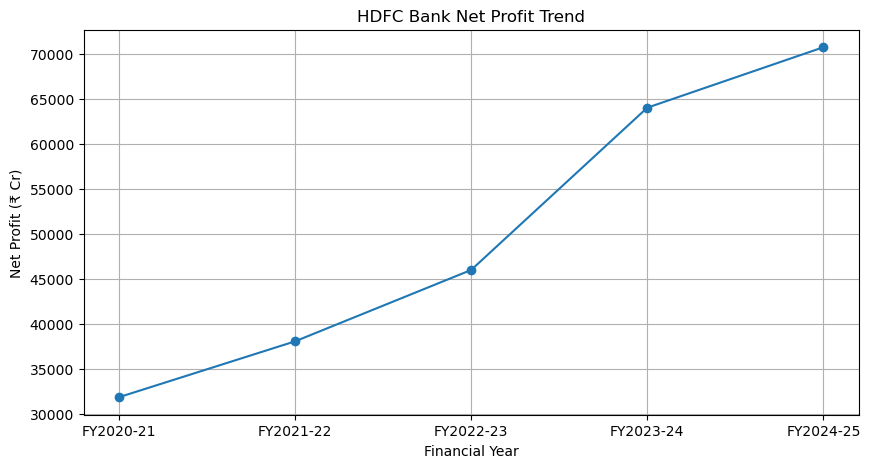

In [46]:
#Net Profit Trend
plt.figure(figsize=(10, 5))

plt.plot(
    profit_loss["financial_year"],
    profit_loss["net_profit"],
    marker="o"
)

plt.title("HDFC Bank Net Profit Trend")
plt.xlabel("Financial Year")
plt.ylabel("Net Profit (₹ Cr)")
plt.grid(True)
plt.show()

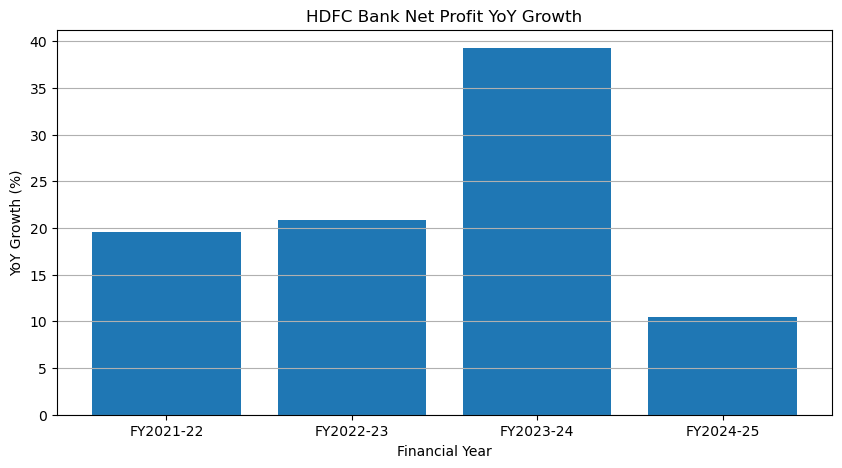

In [47]:
#Net Profit YoY Growth Chart
plt.figure(figsize=(10, 5))

plt.bar(
    profit_loss["financial_year"].iloc[1:],
    profit_loss["net_profit_yoy_pct"].iloc[1:]
)

plt.title("HDFC Bank Net Profit YoY Growth")
plt.xlabel("Financial Year")
plt.ylabel("YoY Growth (%)")
plt.grid(axis="y")
plt.show()

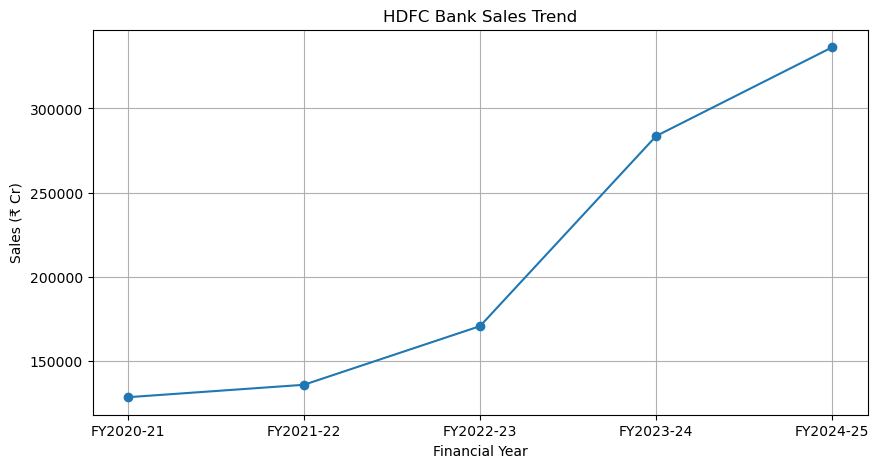

In [48]:
#Sales / Revenue Trend
plt.figure(figsize=(10, 5))

plt.plot(
    profit_loss["financial_year"],
    profit_loss["sales"],
    marker="o"
)

plt.title("HDFC Bank Sales Trend")
plt.xlabel("Financial Year")
plt.ylabel("Sales (₹ Cr)")
plt.grid(True)
plt.show()

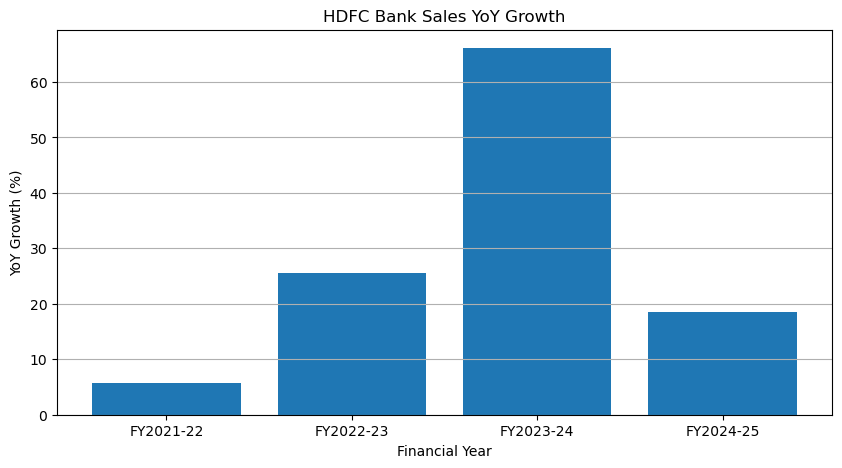

In [49]:
#Sales YoY Growth
plt.figure(figsize=(10, 5))

plt.bar(
    profit_loss["financial_year"].iloc[1:],
    profit_loss["sales_yoy_pct"].iloc[1:]
)

plt.title("HDFC Bank Sales YoY Growth")
plt.xlabel("Financial Year")
plt.ylabel("YoY Growth (%)")
plt.grid(axis="y")
plt.show()

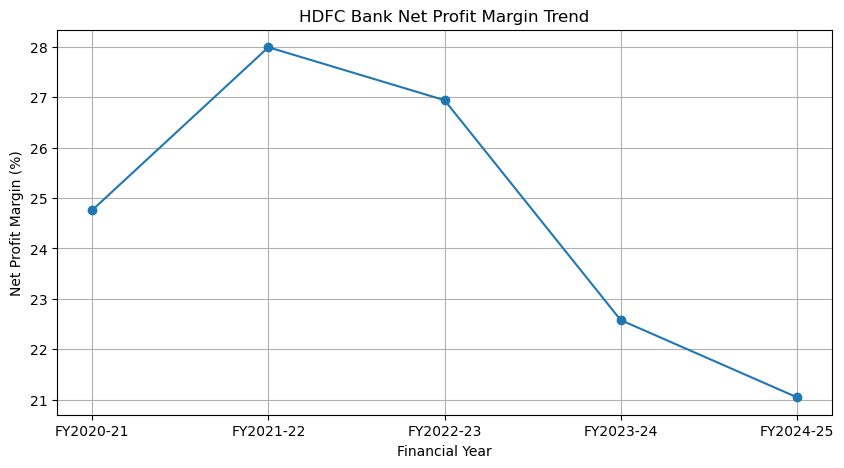

In [50]:
#Net Profit Margin
profit_loss["net_profit_margin_pct"] = (
    profit_loss["net_profit"] / profit_loss["sales"] * 100
).round(2)

plt.figure(figsize=(10, 5))

plt.plot(
    profit_loss["financial_year"],
    profit_loss["net_profit_margin_pct"],
    marker="o"
)

plt.title("HDFC Bank Net Profit Margin Trend")
plt.xlabel("Financial Year")
plt.ylabel("Net Profit Margin (%)")
plt.grid(True)
plt.show()

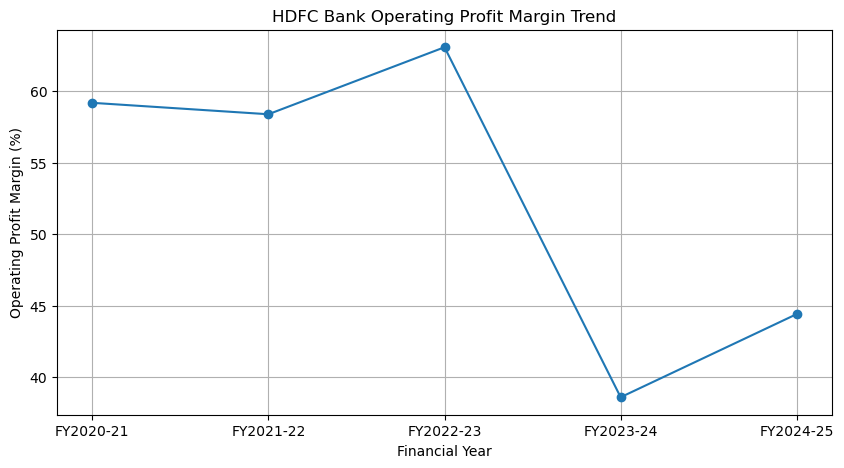

In [51]:
#Operating Profit Margin
profit_loss["operating_profit_margin_pct"] = (
    profit_loss["operating_profit"] / profit_loss["sales"] * 100
).round(2)

plt.figure(figsize=(10, 5))

plt.plot(
    profit_loss["financial_year"],
    profit_loss["operating_profit_margin_pct"],
    marker="o"
)

plt.title("HDFC Bank Operating Profit Margin Trend")
plt.xlabel("Financial Year")
plt.ylabel("Operating Profit Margin (%)")
plt.grid(True)
plt.show()

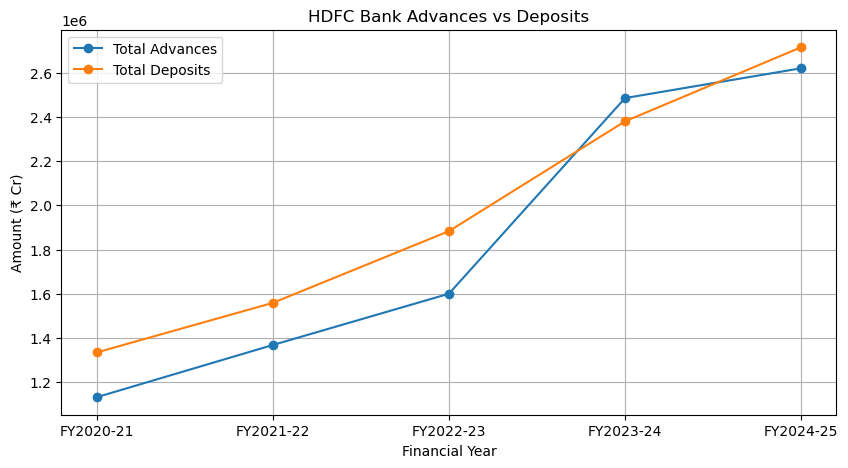

In [52]:
#Advances vs Deposits Growth
plt.figure(figsize=(10, 5))

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["total_advances"],
    marker="o",
    label="Total Advances"
)

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["total_deposits"],
    marker="o",
    label="Total Deposits"
)

plt.title("HDFC Bank Advances vs Deposits")
plt.xlabel("Financial Year")
plt.ylabel("Amount (₹ Cr)")
plt.legend()
plt.grid(True)

plt.show()

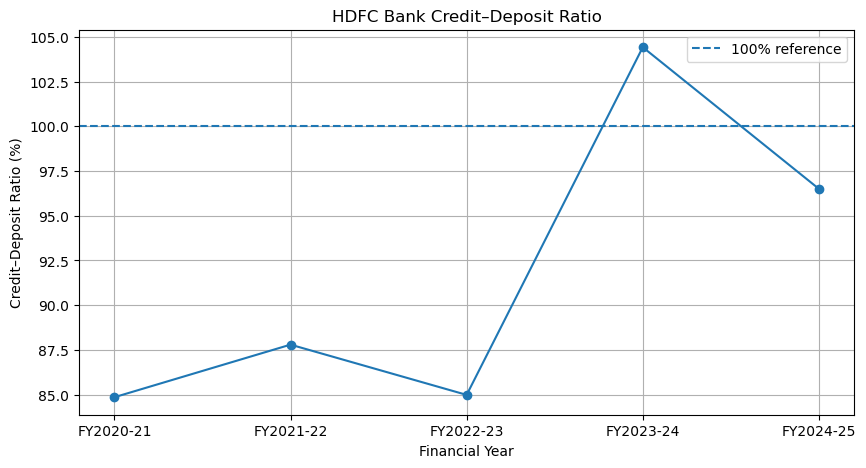

In [53]:
#Credit–Deposit Ratio
banking_kpis["credit_deposit_ratio_pct"] = (
    banking_kpis["total_advances"]
    / banking_kpis["total_deposits"]
    * 100
).round(2)

plt.figure(figsize=(10, 5))

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["credit_deposit_ratio_pct"],
    marker="o"
)

plt.axhline(
    y=100,
    linestyle="--",
    label="100% reference"
)

plt.title("HDFC Bank Credit–Deposit Ratio")
plt.xlabel("Financial Year")
plt.ylabel("Credit–Deposit Ratio (%)")
plt.legend()
plt.grid(True)

plt.show()

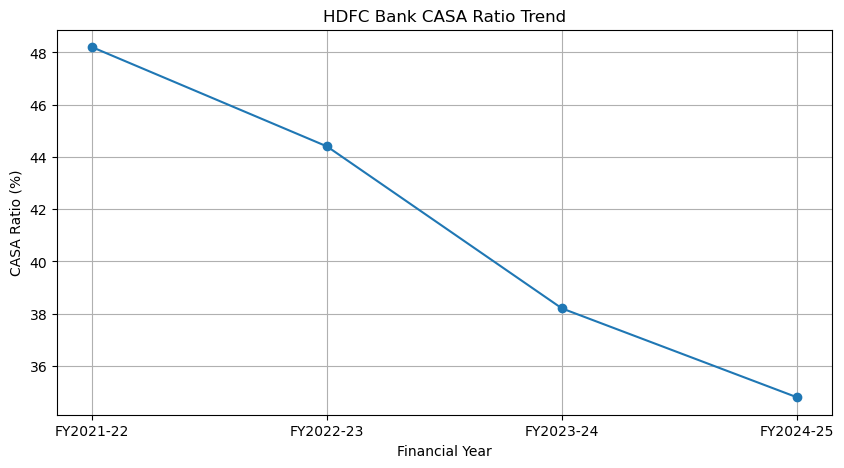

In [54]:
#CASA Ratio Trend
plt.figure(figsize=(10, 5))

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["casa_ratio"],
    marker="o"
)

plt.title("HDFC Bank CASA Ratio Trend")
plt.xlabel("Financial Year")
plt.ylabel("CASA Ratio (%)")
plt.grid(True)

plt.show()

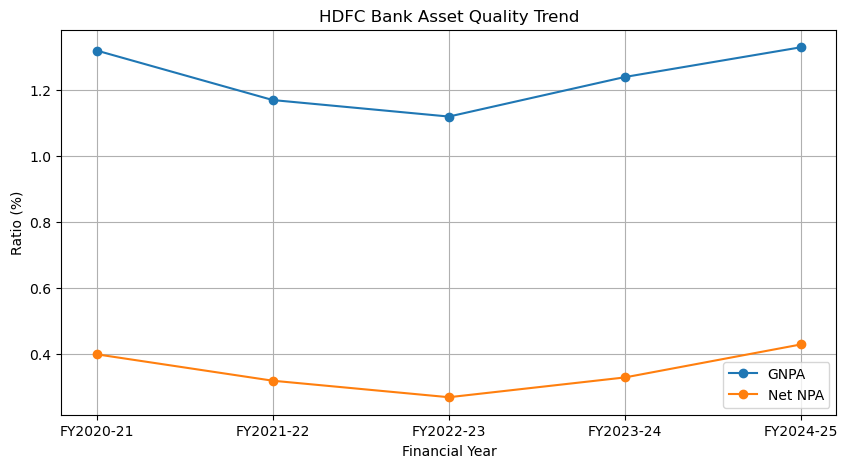

In [55]:
#Asset Quality Trend
plt.figure(figsize=(10, 5))

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["gnpa_ratio"],
    marker="o",
    label="GNPA"
)

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["net_npa_ratio"],
    marker="o",
    label="Net NPA"
)

plt.title("HDFC Bank Asset Quality Trend")
plt.xlabel("Financial Year")
plt.ylabel("Ratio (%)")
plt.legend()
plt.grid(True)

plt.show()

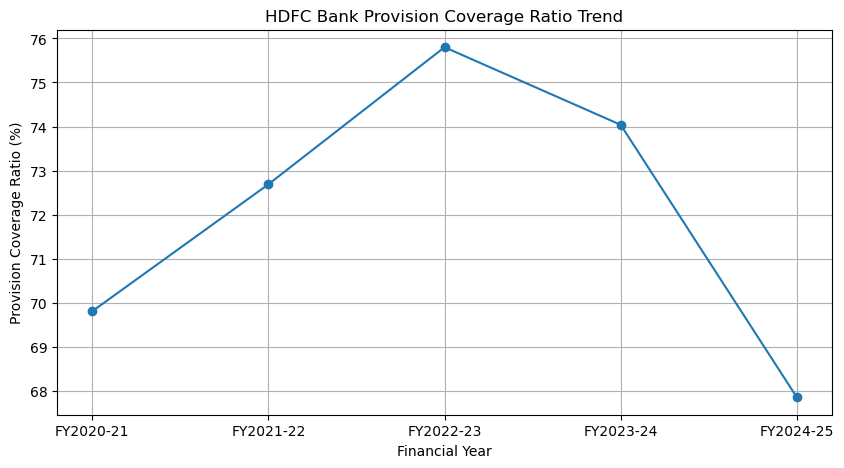

In [56]:
#Provision Coverage Ratio (PCR)
plt.figure(figsize=(10, 5))

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["provision_coverage_ratio"],
    marker="o"
)

plt.title("HDFC Bank Provision Coverage Ratio Trend")
plt.xlabel("Financial Year")
plt.ylabel("Provision Coverage Ratio (%)")
plt.grid(True)

plt.show()

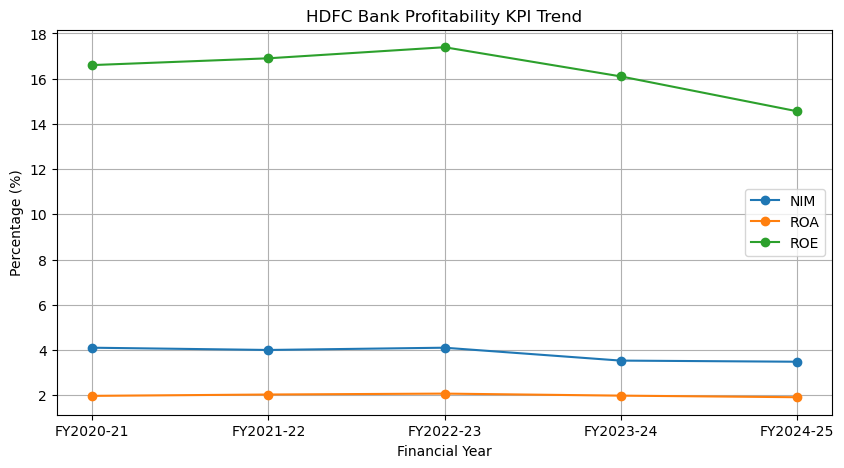

In [57]:
#NIM, ROA & ROE Trend
plt.figure(figsize=(10, 5))

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["nim"],
    marker="o",
    label="NIM"
)

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["roa"],
    marker="o",
    label="ROA"
)

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["roe"],
    marker="o",
    label="ROE"
)

plt.title("HDFC Bank Profitability KPI Trend")
plt.xlabel("Financial Year")
plt.ylabel("Percentage (%)")
plt.legend()
plt.grid(True)

plt.show()

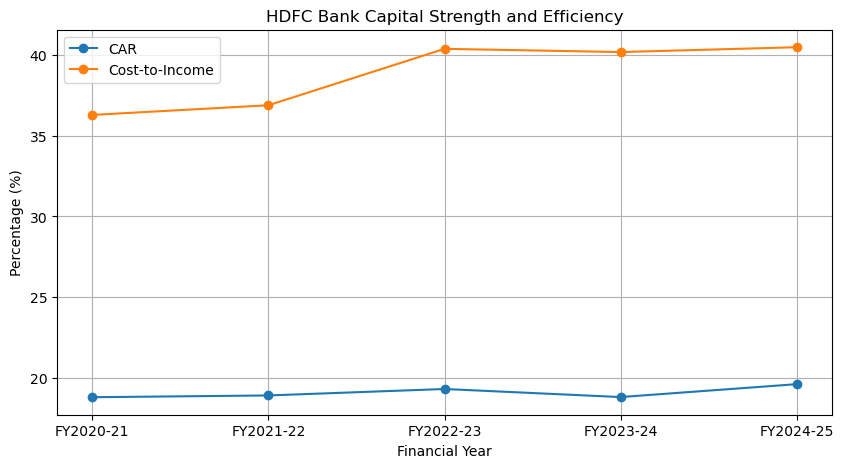

In [58]:
#Capital Strength vs Efficiency
plt.figure(figsize=(10, 5))

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["car"],
    marker="o",
    label="CAR"
)

plt.plot(
    banking_kpis["financial_year"],
    banking_kpis["cost_to_income_ratio"],
    marker="o",
    label="Cost-to-Income"
)

plt.title("HDFC Bank Capital Strength and Efficiency")
plt.xlabel("Financial Year")
plt.ylabel("Percentage (%)")
plt.legend()
plt.grid(True)

plt.show()

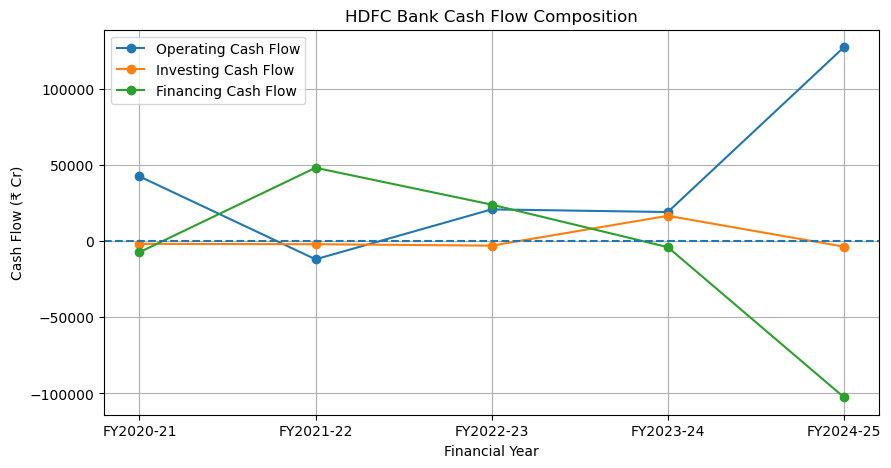

In [59]:
#Cash Flow Composition
plt.figure(figsize=(10, 5))

plt.plot(
    cash_flow["financial_year"],
    cash_flow["cash_from_operating_activity"],
    marker="o",
    label="Operating Cash Flow"
)

plt.plot(
    cash_flow["financial_year"],
    cash_flow["cash_from_investing_activity"],
    marker="o",
    label="Investing Cash Flow"
)

plt.plot(
    cash_flow["financial_year"],
    cash_flow["cash_from_financing_activity"],
    marker="o",
    label="Financing Cash Flow"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("HDFC Bank Cash Flow Composition")
plt.xlabel("Financial Year")
plt.ylabel("Cash Flow (₹ Cr)")
plt.legend()
plt.grid(True)

plt.show()

In [60]:
analysis_df = pd.merge(
    profit_loss[
        [
            "financial_year",
            "sales",
            "net_profit",
            "net_profit_yoy_pct",
            "net_profit_margin_pct"
        ]
    ],
    banking_kpis[
        [
            "financial_year",
            "total_advances",
            "total_deposits",
            "credit_deposit_ratio_pct",
            "casa_ratio",
            "gnpa_ratio",
            "net_npa_ratio",
            "provision_coverage_ratio",
            "nim",
            "roa",
            "roe",
            "car",
            "cost_to_income_ratio"
        ]
    ],
    on="financial_year",
    how="left"
)

analysis_df = pd.merge(
    analysis_df,
    cash_flow[
        [
            "financial_year",
            "cash_from_operating_activity",
            "cash_from_investing_activity",
            "cash_from_financing_activity",
            "net_cash_flow"
        ]
    ],
    on="financial_year",
    how="left"
)

display(analysis_df)

,financial_year,sales,net_profit,net_profit_yoy_pct,net_profit_margin_pct,total_advances,total_deposits,credit_deposit_ratio_pct,casa_ratio,gnpa_ratio,...,provision_coverage_ratio,nim,roa,roe,car,cost_to_income_ratio,cash_from_operating_activity,cash_from_investing_activity,cash_from_financing_activity,net_cash_flow
0,FY2020-21,128552.40,31833.21,NaN,24.76,1132837.0,1335060.0,84.85,NaN,1.32,...,69.81,4.10,1.97,16.60,18.79,36.3,42476.45,-1822.70,-7321.35,33332.40
1,FY2021-22,135936.41,38052.75,19.54,27.99,1368821.0,1559217.0,87.79,48.2,1.17,...,72.69,4.00,2.03,16.90,18.90,36.9,-11959.57,-2051.23,48124.02,34113.22
2,FY2022-23,170754.05,45997.11,20.88,26.94,1600586.0,1883395.0,84.98,44.4,1.12,...,75.80,4.10,2.07,17.39,19.30,40.4,20813.70,-2992.18,23940.56,41762.08
3,FY2023-24,283649.02,64062.04,39.27,22.58,2484862.0,2379786.0,104.42,38.2,1.24,...,74.04,3.53,1.98,16.10,18.80,40.2,19069.34,16600.42,-3983.06,31686.70
4,FY2024-25,336367.43,70792.25,10.51,21.05,2619609.0,2714715.0,96.50,34.8,1.33,...,67.86,3.48,1.91,14.56,19.60,40.5,127241.84,-3650.91,-102477.54,21113.39


In [61]:
analysis_df.to_excel(
    r"D:\real project DA dataset\HDFC bank\HDFC_Bank_Final_Analysis.xlsx",
    index=False
)

print("Final analytical dataset exported successfully!")
print(r"Saved to: D:\real project DA dataset\HDFC bank\HDFC_Bank_Final_Analysis.xlsx")

Final analytical dataset exported successfully!
Saved to: D:\real project DA dataset\HDFC bank\HDFC_Bank_Final_Analysis.xlsx


In [62]:
import os
import pandas as pd

file_path = r"D:\real project DA dataset\HDFC bank\HDFC_Bank_Final_Analysis.xlsx"

print("File exists:", os.path.exists(file_path))

check_df = pd.read_excel(file_path)

print("Rows:", check_df.shape[0])
print("Columns:", check_df.shape[1])

display(check_df)

File exists: True
Rows: 5
Columns: 21


,financial_year,sales,net_profit,net_profit_yoy_pct,net_profit_margin_pct,total_advances,total_deposits,credit_deposit_ratio_pct,casa_ratio,gnpa_ratio,...,provision_coverage_ratio,nim,roa,roe,car,cost_to_income_ratio,cash_from_operating_activity,cash_from_investing_activity,cash_from_financing_activity,net_cash_flow
0,FY2020-21,128552.40,31833.21,NaN,24.76,1132837,1335060,84.85,NaN,1.32,...,69.81,4.10,1.97,16.60,18.79,36.3,42476.45,-1822.70,-7321.35,33332.40
1,FY2021-22,135936.41,38052.75,19.54,27.99,1368821,1559217,87.79,48.2,1.17,...,72.69,4.00,2.03,16.90,18.90,36.9,-11959.57,-2051.23,48124.02,34113.22
2,FY2022-23,170754.05,45997.11,20.88,26.94,1600586,1883395,84.98,44.4,1.12,...,75.80,4.10,2.07,17.39,19.30,40.4,20813.70,-2992.18,23940.56,41762.08
3,FY2023-24,283649.02,64062.04,39.27,22.58,2484862,2379786,104.42,38.2,1.24,...,74.04,3.53,1.98,16.10,18.80,40.2,19069.34,16600.42,-3983.06,31686.70
4,FY2024-25,336367.43,70792.25,10.51,21.05,2619609,2714715,96.50,34.8,1.33,...,67.86,3.48,1.91,14.56,19.60,40.5,127241.84,-3650.91,-102477.54,21113.39
